In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import generate_areas as ga
from image_anal_class import Fringe
%load_ext autoreload
%autoreload 2

In [14]:
img_path = 'drop-211025-2/drop-0100.jpg'

Select = ga.SelectLine(img_path, 'my_window')
line = Select.select_line_from_img()

1: [(172, 348)]
2: [(172, 348), (227, 347)]


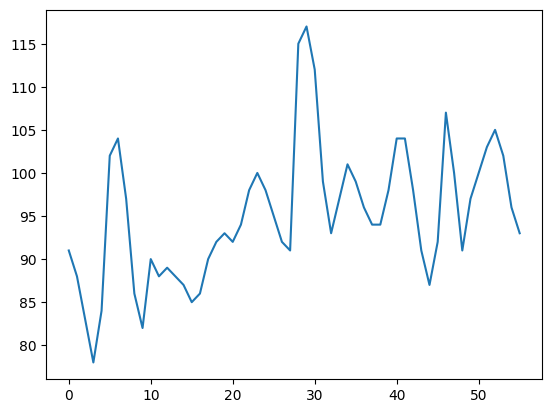

In [15]:
plt.figure()
plt.plot(line)
plt.show()

In [16]:
print(len(line))
dist = np.arange(len(line))

56


# Approximate the indtencity distribution by a function $$ a1+a2*x+a3*x^2 + b1*cos(c1+c2*x) $$
# using scipy function "curve_fit" for determination of coefficients


# Koeffitient "c2" is the frequency of the signal we need to find.

In [17]:
from scipy.optimize import curve_fit

In [47]:
def func(x, a1,a2,a3,b1,c1,c2):
    return a1+a2*x+a3*x**2 + b1*np.cos(c1+c2*x)

In [48]:
popt, pcov = curve_fit(func, dist, line)
print(popt)

[ 8.48506958e+01  6.46410846e-01 -7.35757568e-03  6.19203843e+00
 -1.47434716e-01  1.09015736e+00]


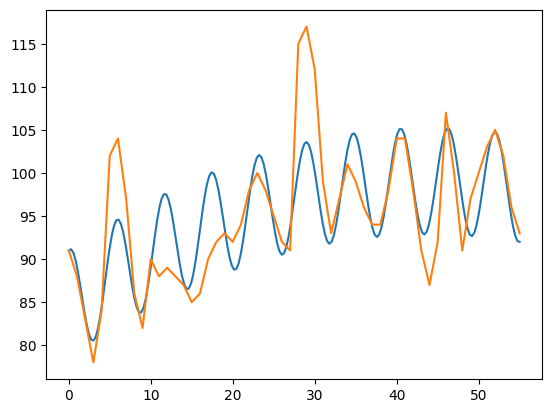

In [49]:
dist_fit = np.linspace(0,55,200)
line_fit = func(dist_fit, *popt)

plt.figure()
plt.plot(dist_fit, line_fit, dist, line)
plt.show()

## Now let's find the frequency of the signal by using phase unwrapping with pre-filtration


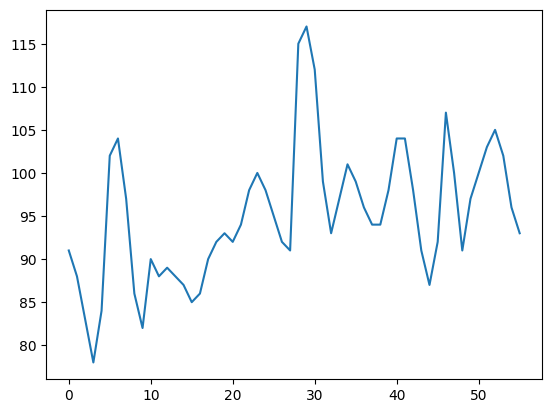

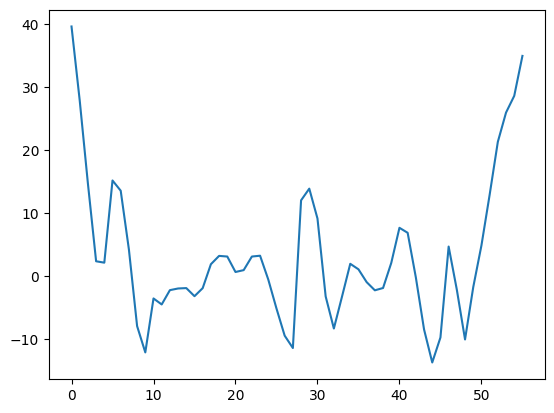

8


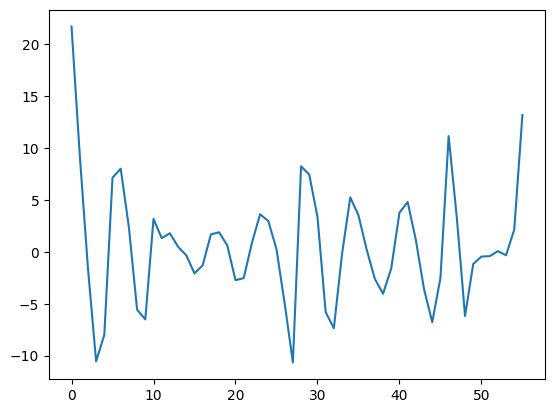

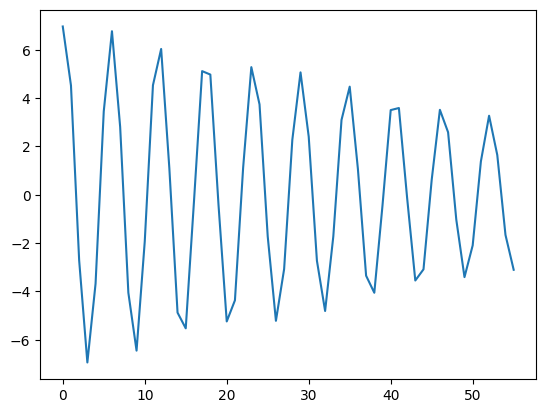

1.0897607487744378


In [67]:
fringe = Fringe(signal = line, fs = 1)
fringe.plot()
fringe.filter_low_frq(nl=3)
fringe.plot()
peak_count = fringe.count_peaks_of_autocorr()
print(peak_count)
fringe.filter_low_frq(nl=peak_count)
fringe.plot()
fringe.update_Wn(rel_h=0.5)
fringe.filter_notch_Wn()
fringe.plot()
frq = fringe.get_frq()
print(frq)

## Testing how selection classes from "generate_areas.py" work

In [4]:
dir_name = 'drop-211025-2'

In [7]:
select = ga.SelectLines(dir_name)

In [34]:
select.get_line_points()

1: [(174, 345)]
2: [(174, 345), (235, 345)]


[(174, 345),
 (175, 345),
 (176, 345),
 (177, 345),
 (178, 345),
 (179, 345),
 (180, 345),
 (181, 345),
 (182, 345),
 (183, 345),
 (184, 345),
 (185, 345),
 (186, 345),
 (187, 345),
 (188, 345),
 (189, 345),
 (190, 345),
 (191, 345),
 (192, 345),
 (193, 345),
 (194, 345),
 (195, 345),
 (196, 345),
 (197, 345),
 (198, 345),
 (199, 345),
 (200, 345),
 (201, 345),
 (202, 345),
 (203, 345),
 (204, 345),
 (205, 345),
 (206, 345),
 (207, 345),
 (208, 345),
 (209, 345),
 (210, 345),
 (211, 345),
 (212, 345),
 (213, 345),
 (214, 345),
 (215, 345),
 (216, 345),
 (217, 345),
 (218, 345),
 (219, 345),
 (220, 345),
 (221, 345),
 (222, 345),
 (223, 345),
 (224, 345),
 (225, 345),
 (226, 345),
 (227, 345),
 (228, 345),
 (229, 345),
 (230, 345),
 (231, 345),
 (232, 345),
 (233, 345),
 (234, 345),
 (235, 345)]

In [35]:
lines = select.get_lines_from_imgs()

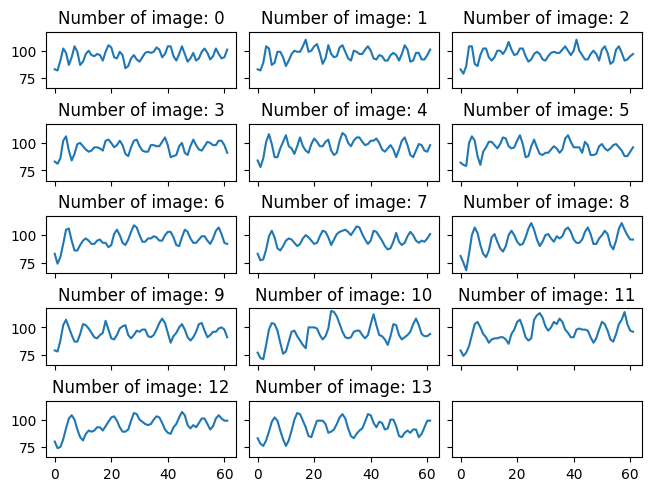

In [36]:
lines.plot()

In [37]:
peak_count = lines.count_peaks_of_autocorr()
peak_count

[20, 20, 21, 20, 17, 18, 19, 20, 20, 21, 20, 22, 21, 18]

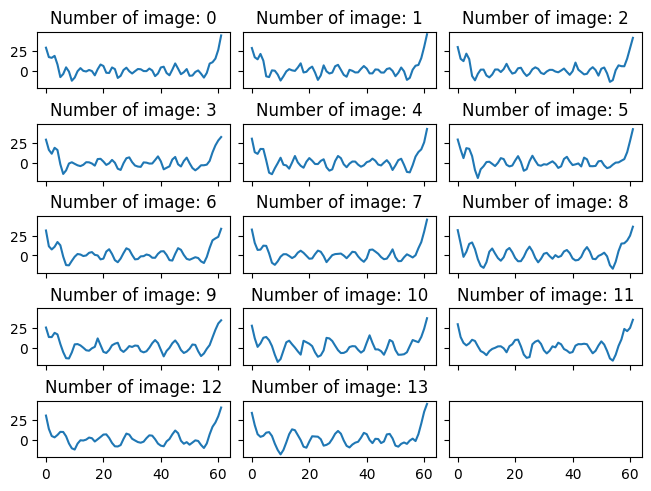

In [38]:
lines.filter_low_frq(4)
lines.plot()

In [39]:
peak_count = lines.count_peaks_of_autocorr()
peak_count

[13, 13, 13, 9, 10, 11, 8, 9, 9, 8, 9, 9, 7, 8]

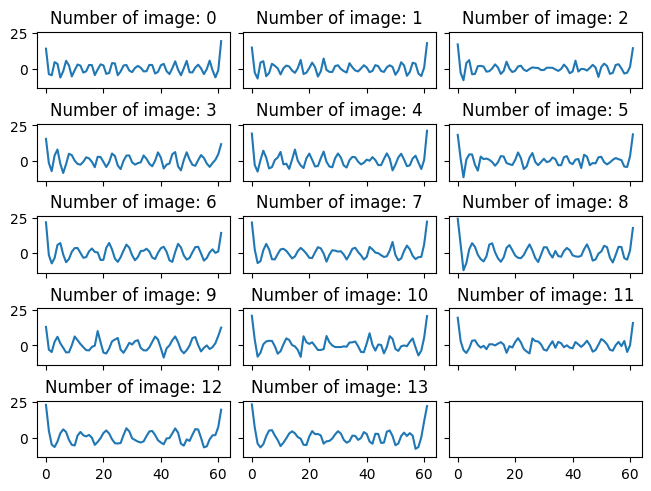

In [40]:
lines.filter_low_frq(peak_count)
lines.plot()

In [41]:
frequency = lines.get_frq()

In [43]:
[fr/2/np.pi for fr in frequency]

[np.float64(0.2415385772555554),
 np.float64(0.22551671610554136),
 np.float64(0.20883172725266366),
 np.float64(0.19751293300714895),
 np.float64(0.18806725505695462),
 np.float64(0.21143447503596113),
 np.float64(0.1672945296549122),
 np.float64(0.1629620300884111),
 np.float64(0.17363470266941672),
 np.float64(0.14755042312905234),
 np.float64(0.1575769164196962),
 np.float64(0.17639099211713624),
 np.float64(0.1317775130411478),
 np.float64(0.16475775165415862)]